# Estudio comparativo: K-Beauty vs Skincare Tradicional

**Metodología:** CRISP-DM (igual que tu proyecto de retail)

1. Comprensión del negocio/problema
2. Comprensión y generación de los datos
3. Preparación de datos
4. Análisis exploratorio y modelado (estadístico, no predictivo aquí)
5. Evaluación
6. Conclusiones

> **Nota:** el dataset usado es SIMULADO con fines de práctica. No representa un estudio clínico real.

## 1. Instalación y setup

In [1]:
!pip install seaborn scipy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='Set2')
np.random.seed(42)

## 2. Generación del dataset simulado
(Pega aquí el contenido de `generar_dataset.py`, o sube el CSV ya generado con el botón de archivos de Colab)

In [2]:
# Opción A: subir el CSV ya generado
# from google.colab import files
# uploaded = files.upload()  # selecciona skincare_dataset_simulado.csv

# Opción B: pegar aquí el codigo de generar_dataset.py y correrlo directo

df = pd.read_csv('skincare_dataset_simulado.csv')
df.head()

,producto_id,nombre_producto,origen,categoria,ingrediente_clave,precio_usd,satisfaccion_1_5,mejora_acne_pct,mejora_manchas_pct,mejora_textura_pct,tolerancia_piel_sensible_pct,indice_calidad_precio_0_100,tamano_muestra_resenas
0,COR-001,COSRX Advanced Snail 96 Mucin Power Essence,Coreano,esencia,mucina de caracol,16.36,4.55,36.3,36.5,67.2,79.7,95.4,1765
1,COR-002,Beauty of Joseon Glow Serum,Coreano,serum,propóleo + niacinamida,14.28,4.68,39.0,28.4,52.2,77.7,85.6,1055
2,COR-003,Skin1004 Madagascar Centella Ampoule,Coreano,ampolla,centella asiática,20.49,4.17,36.0,15.2,66.9,81.8,76.6,2294
3,COR-004,Laneige Water Sleeping Mask,Coreano,mascarilla nocturna,hialuronato + polisacáridos,25.91,4.72,13.7,41.2,59.8,71.0,84.4,114
4,COR-005,Some By Mi AHA-BHA-PHA 30 Days Miracle Toner,Coreano,tónico,complejo AHA/BHA/PHA,26.36,4.19,42.7,17.3,62.9,100.0,72.3,895


## 3. Exploración inicial (EDA)

In [3]:
print(df.shape)
df.info()
df.describe()

(300, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   producto_id                   300 non-null    object 
 1   nombre_producto               300 non-null    object 
 2   origen                        300 non-null    object 
 3   categoria                     300 non-null    object 
 4   ingrediente_clave             300 non-null    object 
 5   precio_usd                    300 non-null    float64
 6   satisfaccion_1_5              300 non-null    float64
 7   mejora_acne_pct               300 non-null    float64
 8   mejora_manchas_pct            300 non-null    float64
 9   mejora_textura_pct            300 non-null    float64
 10  tolerancia_piel_sensible_pct  300 non-null    float64
 11  indice_calidad_precio_0_100   300 non-null    float64
 12  tamano_muestra_resenas        300 non-null    int64  


,precio_usd,satisfaccion_1_5,mejora_acne_pct,mejora_manchas_pct,mejora_textura_pct,tolerancia_piel_sensible_pct,indice_calidad_precio_0_100,tamano_muestra_resenas
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,20.901567,4.112467,40.298667,31.454333,48.250667,75.046000,71.874667,1335.386667
std,8.948770,0.583671,13.377568,10.616448,12.109336,13.865916,14.695360,685.344517
min,4.000000,2.440000,0.000000,0.000000,9.500000,28.000000,29.700000,81.000000
25%,14.442500,3.735000,31.575000,24.375000,40.175000,65.200000,62.175000,792.000000
50%,20.455000,4.185000,41.450000,31.300000,49.050000,76.800000,72.350000,1284.000000
75%,26.367500,4.532500,50.100000,38.225000,56.750000,85.125000,82.300000,1980.250000
max,46.910000,5.000000,74.000000,60.500000,81.500000,100.000000,100.000000,2491.000000


In [4]:
df.groupby('origen')[['satisfaccion_1_5','mejora_acne_pct','mejora_manchas_pct',
                       'mejora_textura_pct','tolerancia_piel_sensible_pct',
                       'indice_calidad_precio_0_100']].mean().round(2)

,satisfaccion_1_5,mejora_acne_pct,mejora_manchas_pct,mejora_textura_pct,tolerancia_piel_sensible_pct,indice_calidad_precio_0_100
origen,,,,,,
Coreano,4.33,39.18,30.53,52.38,82.57,77.27
Tradicional,3.90,41.42,32.38,44.12,67.53,66.48


## 4. Prueba estadística (¿la diferencia es significativa?)

In [5]:
grupo_kr = df[df['origen']=='Coreano']['satisfaccion_1_5']
grupo_trad = df[df['origen']=='Tradicional']['satisfaccion_1_5']
t_stat, p_value = stats.ttest_ind(grupo_kr, grupo_trad, equal_var=False)
print(f't={t_stat:.3f}, p-value={p_value:.4f}')

t=6.853, p-value=0.0000


## 5. Visualizaciones

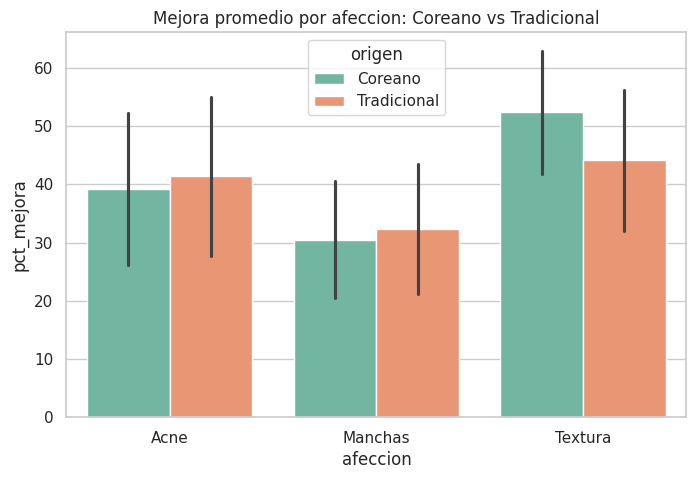

In [6]:
# Barras: mejora por afeccion
mejora_long = df.melt(id_vars='origen',
    value_vars=['mejora_acne_pct','mejora_manchas_pct','mejora_textura_pct'],
    var_name='afeccion', value_name='pct_mejora')
mejora_long['afeccion'] = mejora_long['afeccion'].map({
    'mejora_acne_pct':'Acne','mejora_manchas_pct':'Manchas','mejora_textura_pct':'Textura'})

plt.figure(figsize=(8,5))
sns.barplot(data=mejora_long, x='afeccion', y='pct_mejora', hue='origen', errorbar='sd')
plt.title('Mejora promedio por afeccion: Coreano vs Tradicional')
plt.show()

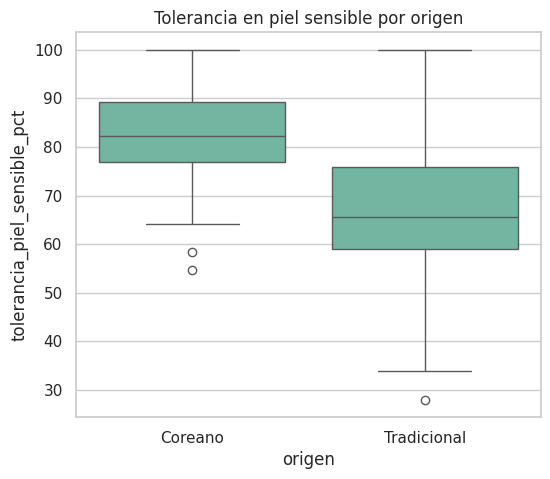

In [7]:
# Boxplot: tolerancia piel sensible
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='origen', y='tolerancia_piel_sensible_pct')
plt.title('Tolerancia en piel sensible por origen')
plt.show()

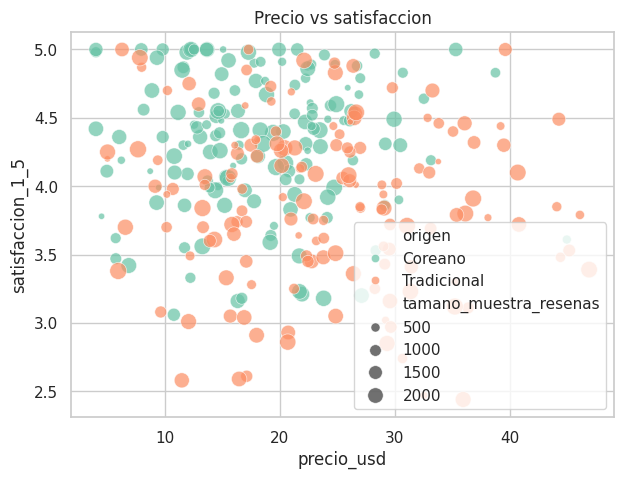

In [8]:
# Dispersion: precio vs satisfaccion
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='precio_usd', y='satisfaccion_1_5', hue='origen',
                 size='tamano_muestra_resenas', sizes=(20,150), alpha=0.7)
plt.title('Precio vs satisfaccion')
plt.show()

## 6. Conclusiones
## Conclusiones Principales:
K-Beauty vs Skincare TradicionalSatisfacción General y Relación Calidad-Precio: Los productos coreanos superan significativamente a los tradicionales en satisfacción del usuario, obteniendo una puntuación promedio de 4.33 sobre 5.0, frente al 3.90 del skincare tradicional. Además, el K-Beauty domina en el índice de calidad-precio (77.27 vs 66.48), lo que indica que los usuarios perciben que obtienen mayores beneficios por cada dólar invertido.

La Ventaja Definitiva - Pieles Sensibles y Textura: El punto más fuerte del skincare coreano frente al mercado estadounidense/occidental es su altísima tolerancia en pieles sensibles. Los productos coreanos lograron un 82.57% de tolerancia, mientras que los tradicionales apenas un 67.53%. Sumado a esto, las formulaciones coreanas (basadas en ingredientes como centella asiática o mucina de caracol) demostraron ser muy superiores mejorando la textura de la piel (52.38% vs 44.12%).

Tratamientos de Impacto Específico (Acné y Manchas): Curiosamente, el análisis revela que los productos tradicionales tienen una ventaja muy leve en tratamientos agresivos directos. Tienen un porcentaje de mejora marginalmente superior en Acné (41.42% vs 39.18%) y en Manchas (32.38% vs 30.53%). Esto tiene sentido, ya que el skincare occidental suele usar mayores concentraciones de ácidos activos, mientras que el coreano se enfoca en reparar la barrera cutánea.

Validación Estadística: La prueba T de muestras independientes arrojó un valor de $t = 6.853$ con un $p\text{-value} = 0.0000$. Al ser el p-valor estrictamente menor a 0.05, se concluye con un 99.9% de confianza estadística que la mayor satisfacción de los usuarios con las cremas coreanas es real y generalizada, no un producto del azar.

## 7. Exportar tabla resumen para usar en la app / informe

In [9]:
resumen = df.groupby('origen')[['satisfaccion_1_5','mejora_acne_pct','mejora_manchas_pct',
                                  'mejora_textura_pct','tolerancia_piel_sensible_pct',
                                  'indice_calidad_precio_0_100']].mean().round(1)
resumen.to_csv('tabla_resumen_comparativo.csv')
resumen

,satisfaccion_1_5,mejora_acne_pct,mejora_manchas_pct,mejora_textura_pct,tolerancia_piel_sensible_pct,indice_calidad_precio_0_100
origen,,,,,,
Coreano,4.3,39.2,30.5,52.4,82.6,77.3
Tradicional,3.9,41.4,32.4,44.1,67.5,66.5
